In [28]:
!pip install tensorflow numpy matplotlib

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import tensorflow as tf

train_data = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/data_fruit/train',
    image_size=(128, 128),
    batch_size=32
)
test_data = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/data_fruit/test',
    image_size=(128, 128),
    batch_size=32
)

Found 3115 files belonging to 36 classes.
Found 359 files belonging to 36 classes.


length of images: 32
length of labels: 32
shape of images: (32, 128, 128, 3)
shape of labels: (32,)


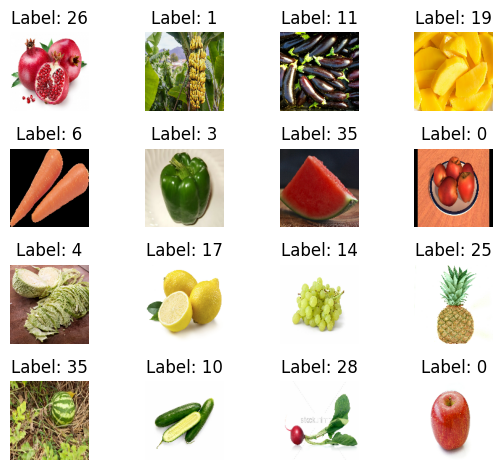

In [31]:
import matplotlib.pyplot as plt

for images, labels in train_data.take(1):
    print(f'length of images: {len(images)}')
    print(f'length of labels: {len(labels)}')
    print(f'shape of images: {images.shape}')
    print(f'shape of labels: {labels.shape}')

    for i in range(16):
        ax = plt.subplot(4,4,i+1)
        # Show image
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Label: {labels[i].numpy()}")
        plt.axis("off")
        plt.tight_layout()
plt.show()

In [32]:
3115/32

97.34375

In [33]:
128*2

256

In [34]:
validation_data = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/data_fruit/validation',
    image_size=(128, 128),
    batch_size=32
)

Found 351 files belonging to 36 classes.


In [35]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])


In [43]:
# =========================
# DATA AUGMENTATION
# =========================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.1),
], name="data_augmentation")

# =========================
# LOAD PRETRAINED MODEL
# =========================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# =========================
# BUILD MODEL
# =========================
inputs = tf.keras.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(36, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
# =========================
# COMPILE MODEL
# =========================
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

# =========================
# CALLBACKS
# =========================
early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=2,

    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(

    'best_mobilenetv2.keras',

    monitor='val_loss',

    save_best_only=True
)

# =========================
# TRAIN MODEL
# =========================
history = model.fit(

    train_data,

    validation_data=validation_data,

    epochs=20,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.1262 - loss: 3.3850 - val_accuracy: 0.4359 - val_loss: 2.5539 - learning_rate: 1.0000e-04
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.4388 - loss: 2.2905 - val_accuracy: 0.6695 - val_loss: 1.5790 - learning_rate: 1.0000e-04
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5740 - loss: 1.6319 - val_accuracy: 0.7265 - val_loss: 1.0741 - learning_rate: 1.0000e-04
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6392 - loss: 1.2988 - val_accuracy: 0.7635 - val_loss: 0.8460 - learning_rate: 1.0000e-04
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6867 - loss: 1.0996 - val_accuracy: 0.8006 - val_loss: 0.6988 - learning_rate: 1.0000e-04
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.7262 - loss: 0.9593 - val_accuracy: 0.8063 - val_loss: 0.6286 - learning_rate: 1.0000e-04
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7413

[0.12616372108459473, 0.4388442933559418, 0.5739967823028564, 0.6391653418540955, 0.6866773962974548, 0.7261637449264526, 0.7412520051002502, 0.7643659710884094, 0.7781701683998108, 0.7852327227592468, 0.7890850901603699, 0.810914933681488, 0.8224719166755676, 0.8211877942085266, 0.843338668346405, 0.8507223129272461, 0.8558587431907654, 0.8510433435440063, 0.8629213571548462, 0.877046525478363]


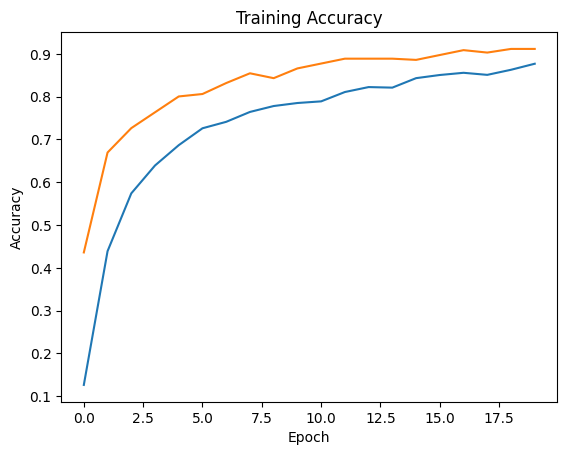

In [51]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
print(history.history['accuracy'])
plt.show()

In [45]:
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


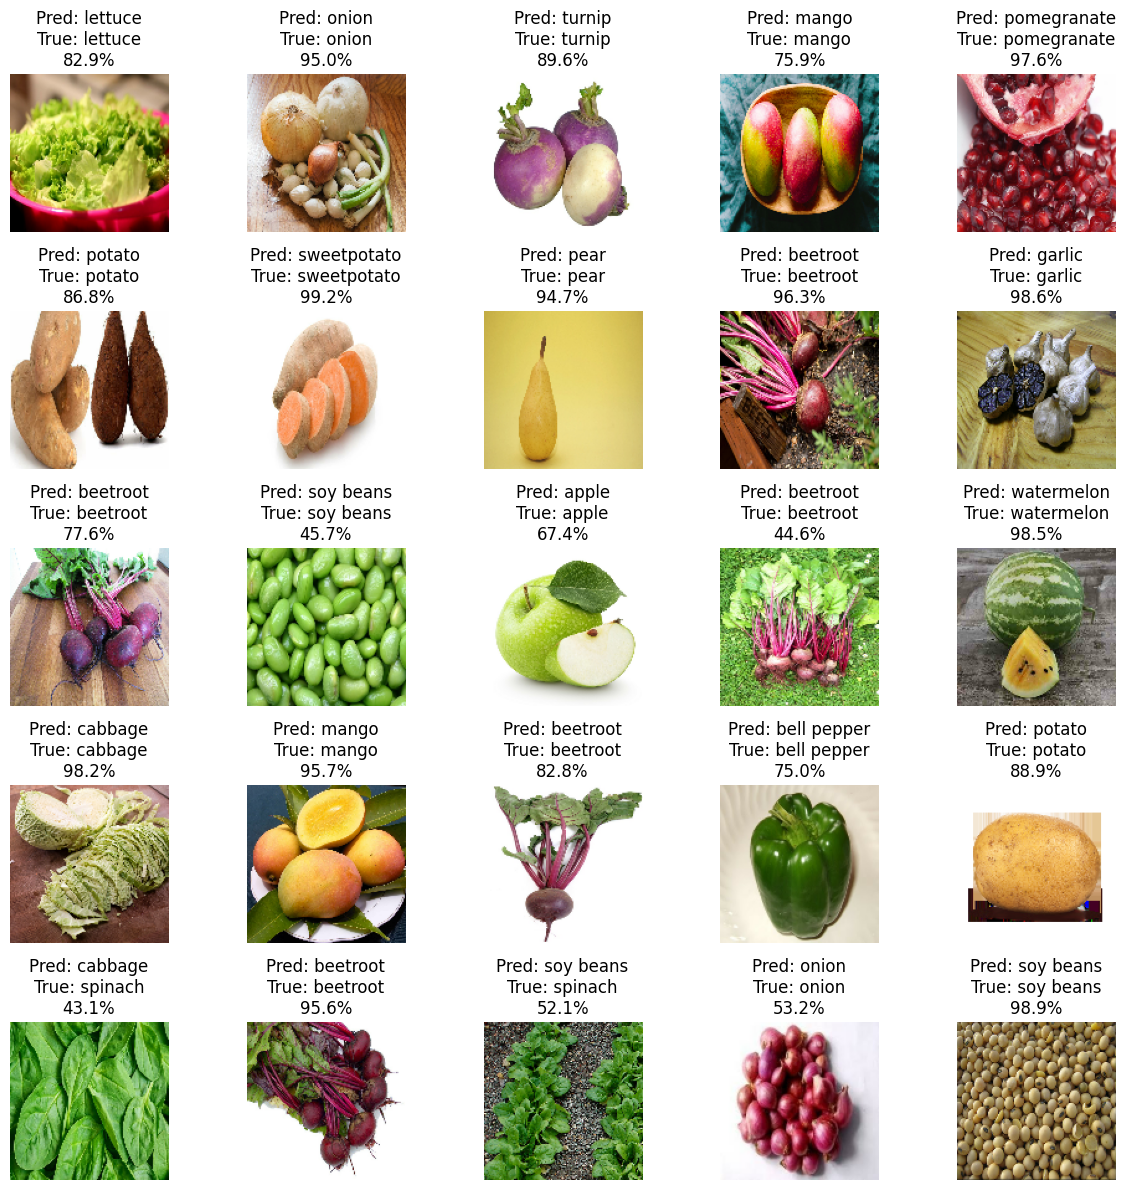

In [49]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(12,12))
class_names = [
    'apple',
    'banana',
    'beetroot',
    'bell pepper',
    'cabbage',
    'capsicum',
    'carrot',
    'cauliflower',
    'chilli pepper',
    'corn',
    'cucumber',
    'eggplant',
    'garlic',
    'ginger',
    'grapes',
    'jalepeno',
    'kiwi',
    'lemon',
    'lettuce',
    'mango',
    'onion',
    'orange',
    'paprika',
    'pear',
    'peas',
    'pineapple',
    'pomegranate',
    'potato',
    'raddish',
    'soy beans',
    'spinach',
    'sweetcorn',
    'sweetpotato',
    'tomato',
    'turnip',
    'watermelon'
]
for images, labels in train_data.take(1):

    predictions = model.predict(images)
    for i in range(25):

        ax = plt.subplot(5,5,i+1)

        # Show image
        plt.imshow(images[i].numpy().astype("uint8"))

        # Prediction
        predicted_class = np.argmax(predictions[i])

        predicted_label = class_names[predicted_class]

        confidence = np.max(predictions[i]) * 100

        true_label = class_names[labels[i]]

        # Title
        plt.title(
            f"Pred: {predicted_label}\n"
            f"True: {true_label}\n"
            f"{confidence:.1f}%"
        )

        plt.axis("off")
plt.tight_layout()
plt.show()

## save model

In [ ]:
model.save('/content/drive/MyDrive/fruit_model__001.keras')